# **MÓDULO 34 - Regressão: Conceitos Avançados**

Para essa atividade vocês trabalharão com a mesma base que usamos na aula, para previsão do aluguel.

Durante a aula montamos um modelo de regressão polinomial utilizando a variavel Valor Condominio para prever a variavel valor aluguel. Nessa atividade vocês devem escolher outra váriavel dessa base para realizar a previsão do valor do aluguel.


Escolhi a metragem porque também tem boa correlação com a variável aluguel já que a professora usou valor do condomínio.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
df_imoveis= pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

In [9]:
df_imoveis.head(5)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


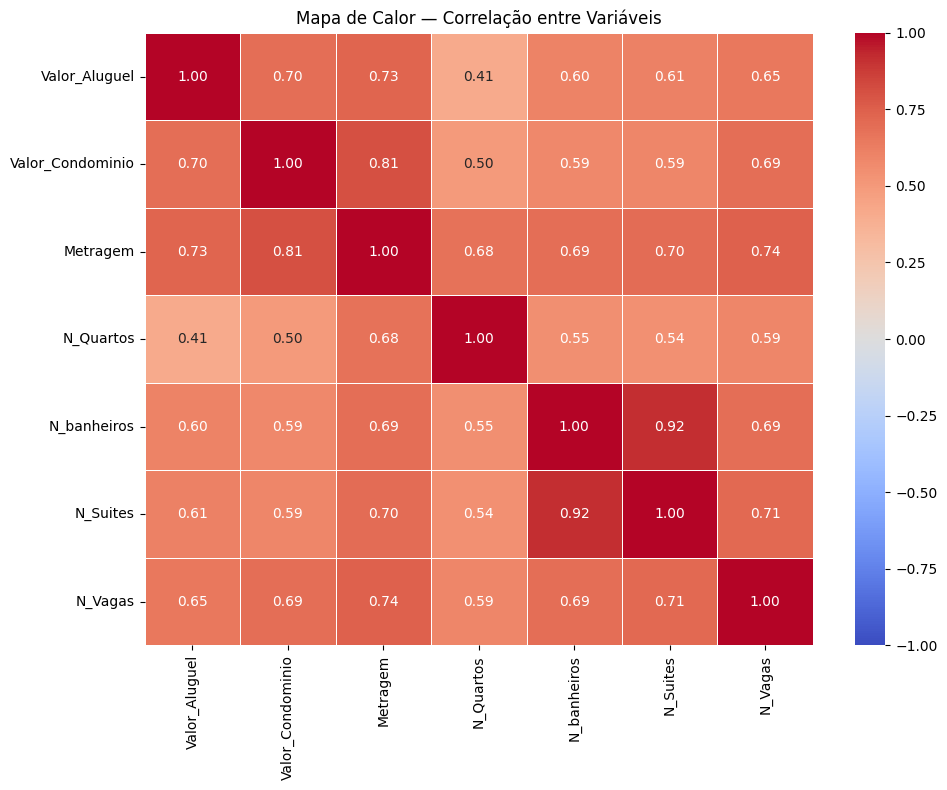

In [10]:
cols = [
    'Valor_Aluguel',
    'Valor_Condominio',
    'Metragem',
    'N_Quartos',
    'N_banheiros',
    'N_Suites',
    'N_Vagas'
]

df_corr = df_imoveis[cols].corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_corr,
    annot=True,       # mostra o valor da correlação
    fmt='.2f',        # 2 casas decimais
    cmap='coolwarm',  # cores para negativa/positiva
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title('Mapa de Calor — Correlação entre Variáveis')
plt.tight_layout()
plt.show()

# 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a usada durante a aula.

In [18]:
X= df_imoveis[['Metragem']]
y= df_imoveis['Valor_Aluguel']

# 2 - Faça o procecssamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [19]:
poly_features= PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
X_poly

array([[1.0000e+00, 4.8000e+01, 2.3040e+03],
       [1.0000e+00, 5.0000e+01, 2.5000e+03],
       [1.0000e+00, 4.0000e+01, 1.6000e+03],
       ...,
       [1.0000e+00, 2.6600e+02, 7.0756e+04],
       [1.0000e+00, 6.0000e+02, 3.6000e+05],
       [1.0000e+00, 2.4800e+02, 6.1504e+04]], shape=(7203, 3))

# 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

In [22]:
X_train, X_test, y_train, y_test, = train_test_split(X_poly, y, test_size=0.2, random_state =0)
model = LinearRegression()
model.fit(X_train, y_train)
LinearRegression()
print("tamanho X_test", X_test.shape)
print("tamanho Y_test", y_test.shape)

tamanho X_test (1441, 3)
tamanho Y_test (1441,)


4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

In [24]:
y_pred = model.predict(X_test)

C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


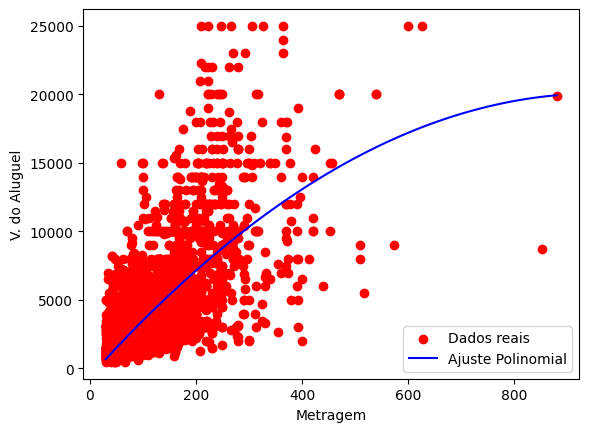

In [28]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_range_pred = model.predict(X_range_poly)
plt.scatter(X, y, color='red', label='Dados reais')
plt.plot(X_range, y_range_pred, color='blue', label='Ajuste Polinomial')
plt.xlabel('Metragem')
plt.ylabel('V. do Aluguel')
plt.legend()
plt.show()

In [31]:
r2=r2_score(y_test, y_pred)
print(f'r2 da polinomial:{r2:.4f}')

r2 da polinomial:0.5423


Um r de 0.54 indica que 54% dos resultados obtidos são explicados pelo modelo. O que não é muito acima de um resultado aleatório que seria 50% de chance de acerto.

# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. Avalie se o resultado desse novo modelo está superior ao anterior.

tamanho X_test (1441, 5)
tamanho Y_test (1441,)


C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


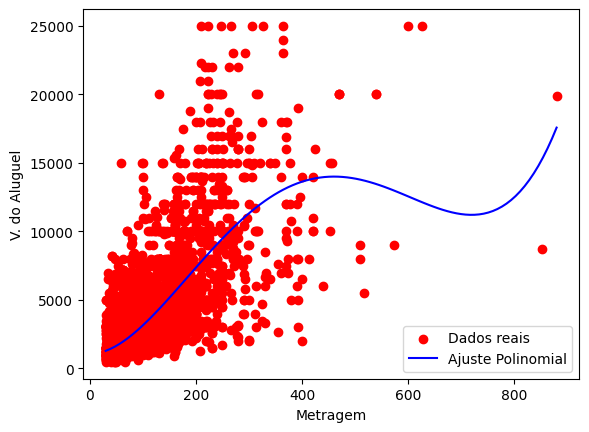

r2 da polinomial:0.5596


In [33]:
X2= df_imoveis[['Metragem']]
y2= df_imoveis['Valor_Aluguel']
poly_features= PolynomialFeatures(degree=4)
X2_poly = poly_features.fit_transform(X2)
X2_poly
X2_train, X2_test, y2_train, y2_test, = train_test_split(X2_poly, y2, test_size=0.2, random_state =0)
model = LinearRegression()
model.fit(X2_train, y2_train)
LinearRegression()
print("tamanho X_test", X2_test.shape)
print("tamanho Y_test", y2_test.shape)
y2_pred = model.predict(X2_test)
X2_range = np.linspace(X2.min(), X2.max(), 100).reshape(-1, 1)
X2_range_poly = poly_features.transform(X2_range)
y2_range_pred = model.predict(X2_range_poly)
plt.scatter(X2, y2, color='red', label='Dados reais')
plt.plot(X2_range, y2_range_pred, color='blue', label='Ajuste Polinomial')
plt.xlabel('Metragem')
plt.ylabel('V. do Aluguel')
plt.legend()
plt.show()
r3=r2_score(y2_test, y2_pred)
print(f'r2 da polinomial:{r3:.4f}')

Elevar os termos a 4 potência não trouxe ganhos significativos para o modelo já que a relção entre metragem e valor do aluguel não apresenta uma curva tão complexa.

# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.
Lasso: o objetivo é reduzir overfitting e selecionar as variáveis ele adiciona um termo de penalização. Essa ferramenta pode excluir termos da equação.
Ridge: também busca reduzir overfitting, ele melhora a generalização reduzindo coeficientes grandes entretanto não elimina nehuma variável.
ElasticNet: funciona como uma fusão de Lasso e Ridge, ele melhora a performance dos modelos com muitas variáveis correlacionadas. Utiliza dois termos de penalização um l1 que leva alguns coeficientes a 0 e o l2 que penaliza apenas o overfitting sem eliminação da variável.

ou a tutora Amanda e corrigirei sua tarefa.

Parabéns pelo empenho e dedicação ao longo do curso !

Você executou todas as etapas esperadas do fluxo do algoritmo: começou pela limpeza e preparação dos dados, tratou corretamente as variáveis categóricas, separou a base de forma adequada, padronizou os dados . Além disso, você aplicou as técnicas necessárias de utilizando o Polynomial Feature e refez os passos testando na fase de processamento o degree 4, além de finalizar com os gráficos de regressão Polinomial. Tudo foi feito de forma organizada e com boa estrutura de raciocínio.

Continue assim, você irá colher muitos frutos pela sua dedicação e empenho.

Bons estudos e conte conosco